In [12]:
from engioptiqa import AnnealingSolverAmplify, TrussStructure, TrussStructureOptimization

In [13]:
ts = TrussStructure()

In [14]:
ts.add_node(0, (0,0))  # Node 0 at (0,0)
ts.add_node(1, (1,0))  # Node 1 at (1,0)
ts.add_node(2, (0,1))  # Node 2 at (0,1)

In [15]:
ts.add_member(0, 1, A=0.5, E=2e11)  # Member from Node 0 to Node 1
ts.add_member(1, 2, A=0.5, E=2e11)  # Member from Node 1 to Node 2

In [16]:
ts.get_member_info()

[{'Member': 0,
  'Node 0': 0,
  'Node 1': 1,
  'Length': 1.0,
  'Direction Cosines (Node 0)': (1.0, 0.0),
  'Direction Cosines (Node 1)': (-1.0, 0.0),
  'Area (A)': 0.5,
  "Young's Modulus (E)": 200000000000.0},
 {'Member': 1,
  'Node 0': 1,
  'Node 1': 2,
  'Length': 1.4142135623730951,
  'Direction Cosines (Node 0)': (-0.7071067811865475, 0.7071067811865475),
  'Direction Cosines (Node 1)': (0.7071067811865475, -0.7071067811865475),
  'Area (A)': 0.5,
  "Young's Modulus (E)": 200000000000.0}]

In [17]:
ts.get_node_info()

{0: (0, 0), 1: (1, 0), 2: (0, 1)}

In [18]:
ts.add_load(1, (0, -100e3))  # Vertical load of -100 N at Node 1

In [19]:
ts.get_load_info()

{1: (0, -100000.0)}

In [20]:
ts.add_support(0, True, True)  # Fixed support at Node 0
ts.add_support(2, True, True)  # Fixed support at Node 2

In [21]:
# Get node information
print("Nodes:")
print(ts.get_node_info())

# Get member information
print("\nMembers:")
for member in ts.get_member_info():
    print(member)

# Get load information
print("\nLoads:")
print(ts.get_load_info())

# Get support information
print("\nSupports:")
print(ts.get_support_info())

Nodes:
{0: (0, 0), 1: (1, 0), 2: (0, 1)}

Members:


{'Member': 0, 'Node 0': 0, 'Node 1': 1, 'Length': 1.0, 'Direction Cosines (Node 0)': (1.0, 0.0), 'Direction Cosines (Node 1)': (-1.0, 0.0), 'Area (A)': 0.5, "Young's Modulus (E)": 200000000000.0}
{'Member': 1, 'Node 0': 1, 'Node 1': 2, 'Length': 1.4142135623730951, 'Direction Cosines (Node 0)': (-0.7071067811865475, 0.7071067811865475), 'Direction Cosines (Node 1)': (0.7071067811865475, -0.7071067811865475), 'Area (A)': 0.5, "Young's Modulus (E)": 200000000000.0}

Loads:
{1: (0, -100000.0)}

Supports:
{0: (True, True), 2: (True, True)}


Max Area: 0.5


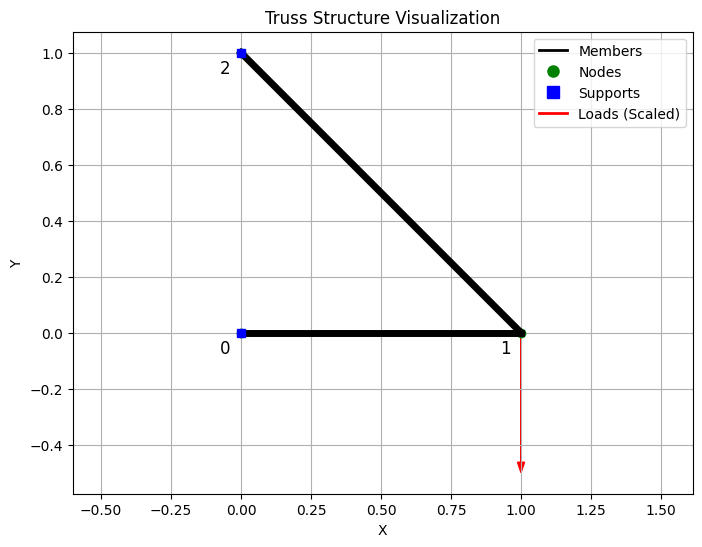

In [22]:
ts.visualize()

In [23]:
member_forces, compliance = ts.compute_member_forces()
print("Member Forces:")
for i_member, force in member_forces.items():
    print(f"\tF_{i_member} = {force} ")

Compliance: 0.38284271247461915
Member Forces:
	F_0 = -100000.00000000004 
	F_1 = 141421.35623730952 


In [24]:
ts.generate_discretization(n_qubits_per_member=5,
                           binary_representation='range',
                           lower_lim=-2e5, upper_lim=3e5)
ts.generate_objective(penalty_weight_joints=1e3)

Node 0
Node 1
	Residual force in x-direction: - 8064.51612903226 q_0 - 16129.0322580645 q_1 - 32258.064516129 q_2 - 64516.1290322581 q_3 - 129032.258064516 q_4 - 5702.474041827 q'_0 - 11404.948083654 q'_1 - 22809.896167308 q'_2 - 45619.792334616 q'_3 - 91239.5846692319 q'_4 + 170710.67811865476
	Residual force in y-direction:  5702.474041827 q'_0 + 11404.948083654 q'_1 + 22809.896167308 q'_2 + 45619.792334616 q'_3 + 91239.5846692319 q'_4 - 170710.67811865476
Node 2


In [25]:
token_dict = {'fixstars': '/usr2/key/Projects/QuantumComputing/QuantumAnnealing/token_Fixstars.txt'}
proxy='http://proxy.ilsb.tuwien.ac.at:3128'
annealing_solver_gpu = AnnealingSolverAmplify(client_type='fixstars', token_file=token_dict['fixstars'], proxy=proxy)
annealing_solver_gpu.setup_solver()

Setting default timeout (ms): 800
Created solver


In [26]:
annealing_solver_gpu.solve_problem(ts)

Number of solutions: 1


In [27]:
best_solution, solutions = ts.analyze_results()

Node 0
Node 1
	Residual force in x-direction: -363.5431361551309
	Residual force in y-direction:  363.5431361551309
Node 2
Best solution (minimum objective):
Objective: 264327223.8834676
Complementary Energy: 0.19245148058034928
Volume: 1.2071067811865475
Joint Residuals (squared): 264327.22369101614
Member Forces: [-100000.0, 141935.48387096776]
Member Stresses: [-200000.0, 283870.9677419355]
Member Areas: [0.5, 0.5]


In [28]:
rel_error_compliance = abs((compliance-2*best_solution["complementary_energy"]))/abs(compliance)
print('Compliance:')
print('===========')
print(f'  Reference: {compliance:.8e}')
print(f'  Solution {2*best_solution["complementary_energy"]:.8e}')
print(f'  Rel. Diff: {rel_error_compliance:.2e}')
print('Force:')
print('======')
for i_member, member in enumerate(ts.members):
    rel_error_force = abs((member_forces[i_member]-best_solution["member_forces"][i_member]))/abs(member_forces[i_member])
    print(f'  Member {i_member}:')
    print(f'    Reference: {member_forces[i_member]:.8e}')
    print(f'    Solution {best_solution["member_forces"][i_member]:.8e}')
    print(f'    Rel. Diff: {rel_error_force:.2e}')

Compliance:
  Reference: 3.82842712e-01
  Solution 3.84902961e-01
  Rel. Diff: 5.38e-03
Force:
  Member 0:
    Reference: -1.00000000e+05
    Solution -1.00000000e+05
    Rel. Diff: 4.37e-16
  Member 1:
    Reference: 1.41421356e+05
    Solution 1.41935484e+05
    Rel. Diff: 3.64e-03
